In [3]:
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve()
while not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.append(str(PROJECT_ROOT))

In [5]:
import pandas as pd

from src.volatility import (
    add_close_to_close_volatility,
    add_parkinson_volatility,
    add_garman_klass_volatility
)

df = pd.read_csv("../data/raw/nifty50.csv", parse_dates=["Date"])
df.set_index("Date", inplace=True)

df = add_close_to_close_volatility(df)
df = add_parkinson_volatility(df)
df = add_garman_klass_volatility(df)

df = df.dropna()
df[["vol_cc","vol_pk","vol_gk"]].head()

,vol_cc,vol_pk,vol_gk
Date,,,
2007-10-16,0.288382,0.282545,0.255859
2007-10-17,0.308638,0.355714,0.359606
2007-10-18,0.331769,0.389630,0.406564
2007-10-19,0.350485,0.406570,0.424694
2007-10-22,0.348319,0.409483,0.430247


In [6]:
df[["vol_cc","vol_pk","vol_gk"]].describe()

,vol_cc,vol_pk,vol_gk
count,4501.000000,4501.000000,4501.000000
mean,0.173330,0.148326,0.145371
std,0.111817,0.097090,0.094294
min,0.050175,0.055065,0.057085
25%,0.107001,0.094189,0.092591
50%,0.143300,0.120275,0.117185
75%,0.193322,0.161173,0.157741
max,0.904851,0.744760,0.714422


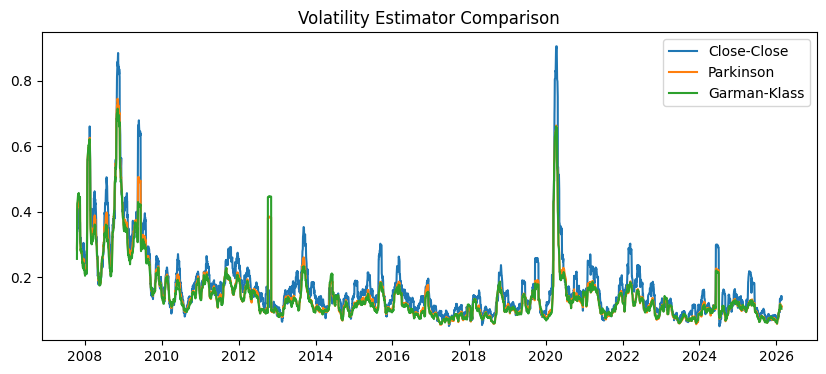

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(df.index, df["vol_cc"], label="Close-Close")
plt.plot(df.index, df["vol_pk"], label="Parkinson")
plt.plot(df.index, df["vol_gk"], label="Garman-Klass")

plt.legend()
plt.title("Volatility Estimator Comparison")
plt.show()

In [9]:
import numpy as np

def make_regime(series):
    q1 = series.quantile(0.33)
    q2 = series.quantile(0.66)

    return pd.cut(
        series,
        bins=[-np.inf, q1, q2, np.inf],
        labels=["Low","Medium","High"]
    )

df["regime_cc"] = make_regime(df["vol_cc"])
df["regime_pk"] = make_regime(df["vol_pk"])
df["regime_gk"] = make_regime(df["vol_gk"])

In [10]:
(df["vol_pk"] >= 0).all(), (df["vol_gk"] >= 0).all()

(np.True_, np.True_)

In [11]:
df[["vol_cc","vol_pk","vol_gk"]].corr()

,vol_cc,vol_pk,vol_gk
vol_cc,1.000000,0.947154,0.924973
vol_pk,0.947154,1.000000,0.995451
vol_gk,0.924973,0.995451,1.000000
